<a href="https://colab.research.google.com/github/Elnathan9414/machine_learning/blob/main/Assignment3_Josue_Mbondo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: CV Model Development, Evaluation, and Optimization

### *Course: DA3C (hCmpVsn) – Computer Vision*
### *Dataset: Breast Ultrasound Images Dataset (BUSI)*
### Student: Josue Elnathan Mbondo
### Instructor Name: Mohamed Ghori

This notebook develops, trains, evaluates, and analyzes computer vision
models for multi-class breast ultrasound image classification.

The notebook follows the problem framing defined in Assignment 1 and
reuses the preprocessing and dataset pipeline prepared in Assignment 2.

## Install Libraries

In [ ]:
! pip install kagglehub

## Import Libraries and Setup

In [ ]:
# Core libraries
import os
import glob
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Image processing
from PIL import Image

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Hardware / GPU check

In [ ]:
# ============================================================
# Hardware / GPU check
# ============================================================

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(" GPU detected.")
    print(f"Number of GPUs: {len(gpus)}")

    for i, gpu in enumerate(gpus):
        print(f"GPU {i}: {gpu}")

    # Enable memory growth when a GPU is available
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print("Memory growth could not be set:", e)

else:
    print(" No GPU detected.")
    print("TensorFlow will use the CPU.")

 GPU detected.
Number of GPUs: 1
GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## Reproducibility

In [ ]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seeds set to:", SEED)

Random seeds set to: 42


## Section 1. Problem Recap and Dataset Overview

### 1.1 Problem Recap

The objective of this project is to develop a computer vision model
that classifies breast ultrasound images into three diagnostic
categories:

- Normal
- Benign
- Malignant

This is a supervised multi-class image classification problem.

The model is intended to support the initial screening process by
helping identify suspicious ultrasound images more efficiently.
It is a decision-support tool and is not intended to replace the
final diagnosis made by qualified healthcare professionals.

The dataset used for this project is the Breast Ultrasound Images
Dataset (BUSI). A subset of 200 images is used, consisting of:

- 70 Benign images
- 70 Malignant images
- 60 Normal images

The input images are grayscale ultrasound images resized to
224 × 224 pixels.
**Learning Style**

The selected learning style is supervised learning because each
ultrasound image is associated with a known diagnostic label.

** Model Family **

Convolutional Neural Networks (CNNs) are used as the primary model
family because they are designed to learn spatial patterns from images.

The candidate approaches defined in Assignment 1 include:

1. Small Custom CNN
2. MobileNetV2 using transfer learning
3. Fine-tuned ResNet50

For this assignment, the Small Custom CNN will be used as a baseline,
while a transfer learning approach will be considered as the primary
model.

 **Evaluation Strategy**

Model performance will be evaluated using:

- Accuracy
- Loss
- Precision
- Recall
- F1-score
- Confusion matrix

Recall for the Malignant class will receive particular attention
because false-negative predictions may represent the most important
error in this medical image classification task.

The original success criterion defined in Assignment 1 is a validation
accuracy of at least 85%, together with low validation loss and good
generalization.

### 1.2 Dataset Loading and Pipeline Preparation

The Breast Ultrasound Images Dataset (BUSI) is loaded from Kaggle using
`kagglehub`.

The dataset contains the three diagnostic classes used in this project:
Normal, Benign, and Malignant.

The original dataset is then used to access the 200-image subset prepared
for this assignment.

In [ ]:
# ============================================================
# Download / load the BUSI dataset
# ============================================================

# Download dataset from Kaggle
kaggle_path = kagglehub.dataset_download(
    "sabahesaraki/breast-ultrasound-images-dataset"
)

print("Kaggle dataset location:")
print(kaggle_path)

# Original BUSI dataset folder
source_dataset = os.path.join(
    kaggle_path,
    "Dataset_BUSI_with_GT"
)

# Local project directory in Colab
PROJECT_DIR = "/content/Assignment3"
DATA_DIR = os.path.join(PROJECT_DIR, "data")

os.makedirs(DATA_DIR, exist_ok=True)

# Local copy of the dataset
destination_dataset = os.path.join(
    DATA_DIR,
    "Dataset_BUSI_with_GT"
)

# Copy dataset only if it does not already exist
if not os.path.exists(destination_dataset):
    shutil.copytree(source_dataset, destination_dataset)
    print("\n Dataset copied successfully.")
else:
    print("\n Dataset already exists locally.")

print("\nLocal dataset:")
print(destination_dataset)


Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
Kaggle dataset location:
/kaggle/input/breast-ultrasound-images-dataset

 Dataset already exists locally.

Local dataset:
/content/Assignment3/data/Dataset_BUSI_with_GT


In [ ]:
# ============================================================
# Create 200-image subset
# ============================================================

full_dataset_path = destination_dataset  # From cell 1neWxU7kyWex
subset_base_dir = os.path.join(DATA_DIR, "breast_cancer_subset_200")

# Define target counts for each class in the subset
subset_counts = {
    "normal": 60,
    "benign": 70,
    "malignant": 70
}

print(f"Creating 200-image subset at: {subset_base_dir}")

# Create the base directory for the subset if it doesn't exist
os.makedirs(subset_base_dir, exist_ok=True)

for cls in CLASSES:
    source_class_dir = os.path.join(full_dataset_path, cls)
    destination_class_dir = os.path.join(subset_base_dir, cls)

    # Create destination class directory
    os.makedirs(destination_class_dir, exist_ok=True)

    # Check if the destination class directory already has the correct number of images
    current_images = [
        f for f in os.listdir(destination_class_dir)
        if f.lower().endswith(".png") and "_mask" not in f.lower()
    ]

    if len(current_images) >= subset_counts[cls]:
        print(f"✅ {cls.capitalize()} subset already has {len(current_images)} images (target: {subset_counts[cls]}). Skipping.")
        continue

    # List all available images for the current class in the full dataset
    all_images_in_class = [
        os.path.join(source_class_dir, filename)
        for filename in os.listdir(source_class_dir)
        if filename.lower().endswith(".png")
        and "_mask" not in filename.lower()
    ]

    # Shuffle and select the required number of images
    random.shuffle(all_images_in_class)
    selected_images = all_images_in_class[:subset_counts[cls]]

    # Copy selected images to the subset directory
    print(f"Copying {len(selected_images)} {cls} images...")
    for img_path in selected_images:
        shutil.copy(img_path, destination_class_dir)

print("\n✅ 200-image subset creation complete.")

Creating 200-image subset at: /content/Assignment3/data/breast_cancer_subset_200
Copying 60 normal images...
Copying 70 benign images...
Copying 70 malignant images...

✅ 200-image subset creation complete.


### 1.3 Dataset Pipeline from Assignment 2

The preprocessing and dataset pipeline developed in Assignment 2 is
reused for model development in this assignment.

The pipeline:
- reads PNG ultrasound images;
- converts images to grayscale;
- resizes images to 224 × 224 pixels;
- normalizes pixel values to [0, 1];
- applies data augmentation only to the training set;
- batches and prefetches data using the TensorFlow `tf.data` API.

#### a.  Dataset and preprocessing configuration

In [ ]:
# ============================================================
# Dataset and preprocessing configuration
# Reused from Assignment 2
# ============================================================

IMG_HEIGHT = 224
IMG_WIDTH = 224
CHANNELS = 1

BATCH_SIZE = 16
SHUFFLE_BUFFER_SIZE = 100

CLASSES = ["normal", "benign", "malignant"]
NUM_CLASSES = len(CLASSES)

print("Image size :", (IMG_HEIGHT, IMG_WIDTH, CHANNELS))
print("Classes    :", CLASSES)
print("Num classes:", NUM_CLASSES)
print("Batch size :", BATCH_SIZE)

Image size : (224, 224, 1)
Classes    : ['normal', 'benign', 'malignant']
Num classes: 3
Batch size : 16


#### b.Image preprocessing

In [ ]:
# ============================================================
# Image preprocessing
# Reused from Assignment 2
# ============================================================

def load_and_preprocess_image(file_path):
    """
    Read a PNG ultrasound image, convert it to grayscale,
    resize it to 224x224, and normalize pixel values to [0, 1].
    """

    # Read image file
    raw_img = tf.io.read_file(file_path)

    # Decode as one-channel grayscale image
    img = tf.io.decode_png(raw_img, channels=1)

    # Resize to model input size
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])

    # Convert to float32 and normalize pixels
    img = tf.cast(img, tf.float32) / 255.0

    return img

#### c.  Data augmentation

In [ ]:
# ============================================================
# Data augmentation
# Reused from Assignment 2
# ============================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name="data_augmentation")

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


#### d. TensorFlow dataset pipeline

In [ ]:
# ============================================================
# TensorFlow dataset pipeline
# ============================================================

def create_tf_dataset(file_paths, labels, is_training=True):
    """
    Create a TensorFlow dataset with:
    - image preprocessing
    - optional shuffling
    - optional augmentation
    - batching
    - prefetching
    """

    ds = tf.data.Dataset.from_tensor_slices(
        (file_paths, labels)
    )

    # Preprocess images
    ds = ds.map(
        lambda x, y: (load_and_preprocess_image(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Training-only operations
    if is_training:
        ds = ds.shuffle(
            buffer_size=SHUFFLE_BUFFER_SIZE,
            seed=SEED
        )

        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    # Batch and prefetch
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

## 1.4 Dataset Preparation

#### Collect image paths from the 200-image subset

In [ ]:
# ============================================================
# Collect image paths from the 200-image subset
# ============================================================

subset_dir = os.path.join(DATA_DIR, "breast_cancer_subset_200")

subset_image_paths = {}

for cls in CLASSES:
    class_dir = os.path.join(subset_dir, cls)

    if not os.path.exists(class_dir):
        raise FileNotFoundError(
            f"Class directory not found: {class_dir}"
        )

    valid_images = [
        os.path.join(class_dir, filename)
        for filename in os.listdir(class_dir)
        if filename.lower().endswith(".png")
        and "_mask" not in filename.lower()
    ]

    subset_image_paths[cls] = sorted(valid_images)

# Display class counts
print("=== SUBSET CLASS DISTRIBUTION ===")

total_images = 0

for cls in CLASSES:
    count = len(subset_image_paths[cls])
    total_images += count
    print(f"{cls:<10}: {count} images")

print(f"Total      : {total_images} images")

=== SUBSET CLASS DISTRIBUTION ===
normal    : 60 images
benign    : 70 images
malignant : 70 images
Total      : 200 images


#### Create image paths and integer labels

#### Verify label distribution

In [ ]:
# Verify label distribution
print("\n=== LABEL DISTRIBUTION ===")

for cls, idx in class_to_idx.items():
    count = np.sum(all_labels == idx)
    print(f"{cls:<10}: {count}")


=== LABEL DISTRIBUTION ===
normal    : 60
benign    : 70
malignant : 70


In [ ]:
# ============================================================
# Create image paths and integer labels
# ============================================================

CLASSES = ["normal", "benign", "malignant"]

class_to_idx = {
    cls: idx for idx, cls in enumerate(CLASSES)
}

all_paths = []
all_labels = []

for cls in CLASSES:
    class_dir = os.path.join(subset_dir, cls)

    for filename in os.listdir(class_dir):
        if filename.lower().endswith(".png") and "_mask" not in filename.lower():
            all_paths.append(os.path.join(class_dir, filename))
            all_labels.append(class_to_idx[cls])

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

print("Total images:", len(all_paths))
print("Class mapping:", class_to_idx)

Total images: 200
Class mapping: {'normal': 0, 'benign': 1, 'malignant': 2}


## Section 2. Train/Validation/Test Strategy and Baseline

### 2.1 Train / Validation / Test Split Strategy

The dataset was divided into three subsets using a stratified split:

- 70% training set: 140 images
- 15% validation set: 30 images
- 15% test set: 30 images

A stratified split was selected to preserve the proportion of the
Normal, Benign, and Malignant classes across the three subsets.

The training set is used to learn the model parameters. The validation
set is used during model development to monitor generalization and
guide model selection. The test set is kept separate and is reserved
for the final evaluation of the selected model.

Data augmentation is applied only to the training set. Validation and
test images are processed without augmentation to provide an unbiased
evaluation of model performance.

#### a. Stratified Train / Validation / Test split

In [ ]:


# ============================================================
# Stratified Train / Validation / Test split
# ============================================================

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=all_labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("=== DATASET SPLIT ===")
print(f"Training   : {len(train_paths)} images")
print(f"Validation : {len(val_paths)} images")
print(f"Test       : {len(test_paths)} images")
print(f"Total      : {len(train_paths) + len(val_paths) + len(test_paths)} images")

=== DATASET SPLIT ===
Training   : 140 images
Validation : 30 images
Test       : 30 images
Total      : 200 images


#### b. Check for overlap between splits

In [ ]:
# ============================================================
# Check for overlap between splits
# ============================================================

train_set = set(train_paths)
val_set = set(val_paths)
test_set = set(test_paths)

train_val_overlap = train_set.intersection(val_set)
train_test_overlap = train_set.intersection(test_set)
val_test_overlap = val_set.intersection(test_set)

print("=== SPLIT OVERLAP CHECK ===")
print("Train / Validation overlap:", len(train_val_overlap))
print("Train / Test overlap      :", len(train_test_overlap))
print("Validation / Test overlap :", len(val_test_overlap))

=== SPLIT OVERLAP CHECK ===
Train / Validation overlap: 0
Train / Test overlap      : 0
Validation / Test overlap : 0


In [ ]:
# ============================================================
# Verify class distribution in each split
# ============================================================

def show_split_distribution(labels, split_name):
    print(f"\n=== {split_name} CLASS DISTRIBUTION ===")

    for cls, idx in class_to_idx.items():
        count = np.sum(labels == idx)
        percentage = (count / len(labels)) * 100

        print(
            f"{cls:<10}: {count:>2} images "
            f"({percentage:.1f}%)"
        )


show_split_distribution(train_labels, "TRAIN")
show_split_distribution(val_labels, "VALIDATION")
show_split_distribution(test_labels, "TEST")


=== TRAIN CLASS DISTRIBUTION ===
normal    : 42 images (30.0%)
benign    : 49 images (35.0%)
malignant : 49 images (35.0%)

=== VALIDATION CLASS DISTRIBUTION ===
normal    :  9 images (30.0%)
benign    : 10 images (33.3%)
malignant : 11 images (36.7%)

=== TEST CLASS DISTRIBUTION ===
normal    :  9 images (30.0%)
benign    : 11 images (36.7%)
malignant : 10 images (33.3%)


### 2.2 Baseline Model Selection

A small custom Convolutional Neural Network (CNN) is selected as the
baseline model.

The baseline is intentionally simple and lightweight. It provides a
reference point for evaluating more advanced approaches later in the
assignment.

The Small Custom CNN was selected because:

- it is computationally lightweight;
- it can be trained directly on the grayscale ultrasound images;
- it provides a simple reference for model comparison;
- it is suitable for the relatively small dataset used in this project.

A limitation is the higher risk of overfitting because the dataset
contains only 200 images.

In [ ]:
# ============================================================
# Baseline: Small Custom CNN
# ============================================================

baseline_model = tf.keras.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1)),

    # Convolutional block 1
    layers.Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convolutional block 2
    layers.Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convolutional block 3
    layers.Conv2D(
        128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Classification head
    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    # Three diagnostic classes
    layers.Dense(NUM_CLASSES, activation="softmax")
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,243 (49.36 MB)

 Trainable params: 12,938,243 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# Compile baseline model
# ============================================================

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Baseline model compiled.")

✅ Baseline model compiled.


### 2.3 Success Criteria

The main project success criterion is a validation accuracy of at least
85%, as defined in Assignment 1.

However, accuracy alone is not sufficient for this medical image
classification problem.

The following metrics will therefore be considered:

- Accuracy: overall classification performance.
- Precision: how many predicted positive cases are correct.
- Recall: the ability to identify cases belonging to a class.
- F1-score: the balance between precision and recall.
- Confusion matrix: class-level error analysis.
- Validation loss: an indicator of model generalization during training.

Particular attention will be given to recall for the Malignant class,
because false-negative predictions may be especially important in the
screening context.

The baseline model provides a reference point for comparing the
performance of the primary model and later optimization experiments.

### 2.4 Baseline Training

In [ ]:
# ============================================================
# Training callbacks
# ============================================================

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
# ============================================================
# Create TensorFlow datasets
# ============================================================

train_ds = create_tf_dataset(
    train_paths,
    train_labels,
    is_training=True
)

val_ds = create_tf_dataset(
    val_paths,
    val_labels,
    is_training=False
)

test_ds = create_tf_dataset(
    test_paths,
    test_labels,
    is_training=False
)

print("✅ train_ds, val_ds and test_ds created successfully.")

✅ train_ds, val_ds and test_ds created successfully.


In [ ]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.5643 - loss: 0.8836 - val_accuracy: 0.5333 - val_loss: 0.8782
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.5929 - loss: 0.8739 - val_accuracy: 0.6333 - val_loss: 0.8389
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - accuracy: 0.6143 - loss: 0.8277 - val_accuracy: 0.6333 - val_loss: 0.9413
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - accuracy: 0.6071 - loss: 0.8484 - val_accuracy: 0.6000 - val_loss: 0.8723
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 211ms/step - accuracy: 0.6286 - loss: 0.8190 - val_accuracy: 0.7000 - val_loss: 0.7917
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.6071 - loss: 0.8063 - val_accuracy: 0.6000 - val_loss: 0.8312
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.6071 - loss: 0.8747 - val_accuracy: 0.6667 - val_loss: 0.8803
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 0.6357 - loss: 0.7634 - val_accuracy: 0.6333 - val_loss:

In [ ]:
# ============================================================
# Training summary
# ============================================================

epochs_completed = len(history_baseline.history["loss"])

print(f"Training completed after {epochs_completed} epochs.")

print(
    f"Best validation accuracy: "
    f"{max(history_baseline.history['val_accuracy']):.4f}"
)

print(
    f"Best validation loss: "
    f"{min(history_baseline.history['val_loss']):.4f}"
)

Training completed after 24 epochs.
Best validation accuracy: 0.7333
Best validation loss: 0.7235


***Baseline Training Results***

The Small Custom CNN was trained for a maximum of 30 epochs with
early stopping based on validation loss.

The training stopped after 24 epochs, and the model restored the
weights from epoch 16, which produced the best validation loss.

The best validation performance was:

- Validation accuracy: 73.33%
- Validation loss: 0.7235

The validation accuracy is below the project target of 85% defined in
Assignment 1. Therefore, the baseline does not meet the target
performance and provides a reference point for evaluating the primary
model and subsequent optimization techniques.

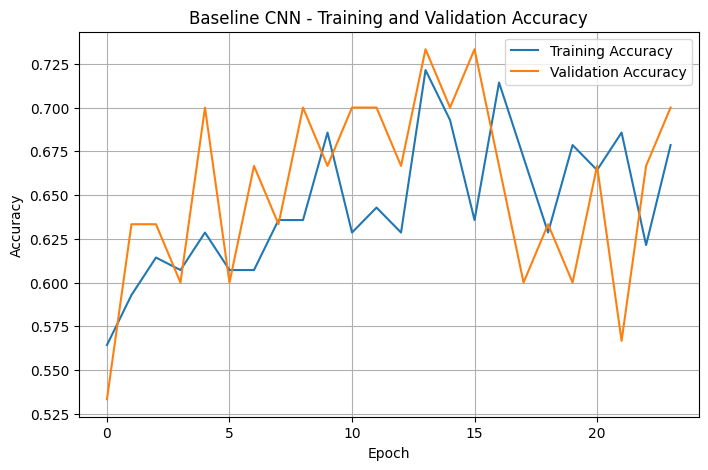

In [ ]:
# ============================================================
# Accuracy curves
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_baseline.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Baseline CNN - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

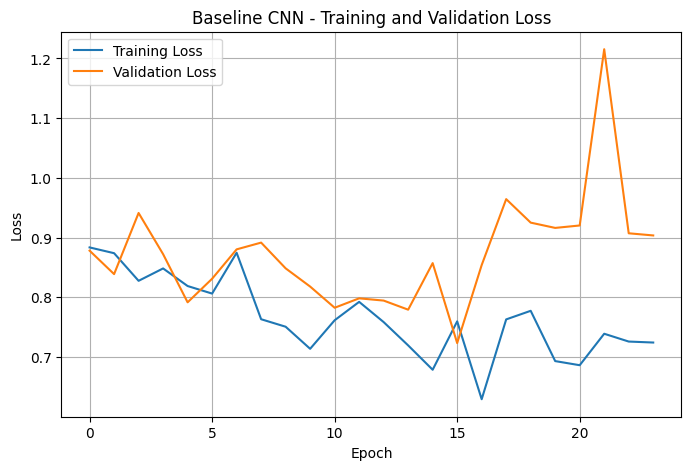

In [ ]:
# ============================================================
# Loss curves
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_baseline.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline CNN - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

***Baseline Training Diagnostics***

The baseline CNN achieved a best validation accuracy of 73.33% at
epoch 16, which is below the project target of 85%.

The training accuracy increased progressively, while the validation
accuracy showed substantial fluctuations throughout training. The
training loss generally decreased, whereas the validation loss
increased after approximately epoch 16 and showed several large
fluctuations.

This pattern provides evidence of overfitting: the model continues to
fit the training data while its generalization performance becomes
less stable on the validation set. The EarlyStopping callback
therefore restored the weights from epoch 16, corresponding to the
best validation performance.

The relatively small validation set of 30 images should also be
considered when interpreting these results. With such a small sample,
individual predictions can produce noticeable changes in validation
accuracy from one epoch to another.

Overall, the baseline provides a useful reference point, but its
validation performance does not meet the 85% target. A more effective
model or optimization strategy will therefore be investigated in the
next sections.

### 2.5 Baseline Evaluation on the Test Set

The baseline model is evaluated on the held-out test set, which was not
used during model training or model selection.

Predictions are compared with the true class labels to calculate
overall and per-class performance metrics.

In [ ]:
# ============================================================
# Generate baseline predictions on the test set
# ============================================================

y_true = []
y_pred = []

for images, labels in test_ds:
    probabilities = baseline_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(probabilities, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of test samples:", len(y_true))

Number of test samples: 30


In [ ]:
# ============================================================
# Test accuracy
# ============================================================

test_accuracy = accuracy_score(y_true, y_pred)

print(f"Baseline Test Accuracy: {test_accuracy:.4f}")
print(f"Baseline Test Accuracy: {test_accuracy * 100:.2f}%")

Baseline Test Accuracy: 0.6000
Baseline Test Accuracy: 60.00%


In [ ]:
# ============================================================
# Classification report
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASSES,
    digits=4
)

print(report)

              precision    recall  f1-score   support

      normal     0.5000    0.8889    0.6400         9
      benign     0.6364    0.6364    0.6364        11
   malignant     1.0000    0.3000    0.4615        10

    accuracy                         0.6000        30
   macro avg     0.7121    0.6084    0.5793        30
weighted avg     0.7167    0.6000    0.5792        30



***Baseline Test Evaluation***

The baseline CNN achieved a test accuracy of 60.00%, which is below
the project's target of 85%.

The class-level results show substantial differences in performance.
The Normal class achieved a recall of 88.89%, while the Benign class
achieved a recall of 63.64%.

The most important result concerns the Malignant class. Although the
model achieved a precision of 100.00% for Malignant, its recall was
only 30.00%. This means that the model correctly identified only 3 of
the 10 malignant test images and missed 7 malignant cases.

This low malignant recall is a significant limitation because false
negative predictions are particularly important in the context of
breast cancer screening.

Overall, the baseline model is useful as a reference point but does
not provide sufficient performance for the project's objective. A
stronger model should therefore improve not only overall accuracy but
also the ability to detect malignant cases.

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2]
)

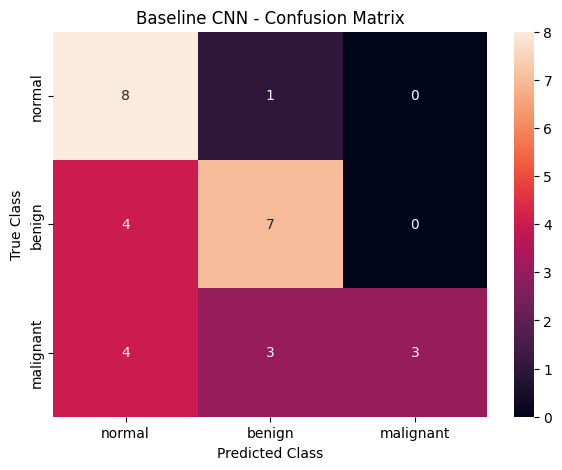

In [ ]:
# ============================================================
# Baseline confusion matrix
# ============================================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.title("Baseline CNN - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

In [ ]:
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[8 1 0]
 [4 7 0]
 [4 3 3]]


***Baseline Confusion Matrix Analysis***

The confusion matrix provides a detailed view of the classification
errors made by the baseline CNN.

The model correctly classified 8 of 9 Normal images, resulting in a
recall of 88.89% for the Normal class. For the Benign class, 7 of 11
images were correctly classified, resulting in a recall of 63.64%.

The most important weakness is observed for the Malignant class. Only
3 of the 10 malignant images were correctly identified, while 4 were
classified as Normal and 3 were classified as Benign. This resulted in
a malignant recall of only 30.00%.

Although the precision for the Malignant class was 100.00%, the low
recall indicates that the model was too conservative when predicting
Malignant cases. In a breast cancer screening context, these false
negative predictions are particularly important because potentially
malignant cases may be missed.

Overall, the confusion matrix confirms that the baseline CNN is not
sufficient for the project's objective. Improving malignant detection
will therefore be an important focus of the primary model.

## Section 3. Primary Model Implementation


### 3.1 Primary Model: MobileNetV2 Transfer Learning

MobileNetV2 is selected as the primary model using transfer learning.

This approach is appropriate for the project because the dataset contains
only 200 ultrasound images. Instead of learning all visual features from
scratch, the model uses a pretrained convolutional network as a feature
extractor and adapts the final classification layers to the three BUSI
diagnostic classes:

- Normal
- Benign
- Malignant

The goal is to determine whether transfer learning can improve upon the
performance of the small custom CNN baseline, particularly for the
Malignant class.

### 3.2 Convert grayscale images to 3 channels for MobileNetV2

In [ ]:
# ============================================================
# Convert grayscale images to 3 channels for MobileNetV2
# ============================================================

def convert_to_rgb(image, label):
    """
    Convert a grayscale image (224, 224, 1) into a
    3-channel image (224, 224, 3).
    """
    image = tf.image.grayscale_to_rgb(image)
    return image, label


train_rgb_ds = train_ds.map(
    convert_to_rgb,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_rgb_ds = val_ds.map(
    convert_to_rgb,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_rgb_ds = test_ds.map(
    convert_to_rgb,
    num_parallel_calls=tf.data.AUTOTUNE
)

print(" RGB datasets created for MobileNetV2.")

 RGB datasets created for MobileNetV2.


In [ ]:
# Verify MobileNetV2 input shape

images, labels = next(iter(train_rgb_ds))

print("Train batch image shape:", images.shape)
print("Train batch label shape:", labels.shape)

Train batch image shape: (16, 224, 224, 3)
Train batch label shape: (16,)


### 3.3 Load pretrained MobileNetV2

In [ ]:
# ============================================================
# Load pretrained MobileNetV2
# ============================================================

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

print(" MobileNetV2 loaded.")
print("Trainable:", base_model.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 MobileNetV2 loaded.
Trainable: False


In [ ]:
# ============================================================
# Build MobileNetV2 classification model
# ============================================================

inputs = layers.Input(shape=(224, 224, 3))

# MobileNetV2 expects inputs in the range it was pretrained on.
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

# Feature extraction
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

primary_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="MobileNetV2_BUSI"
)

primary_model.summary()

Model: "MobileNetV2_BUSI"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ============================================================
# Compile primary model
# ============================================================

primary_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(" Primary model compiled.")

 Primary model compiled.


### 3.4 Primary Model Training

The MobileNetV2 model is first trained with its pretrained convolutional
base frozen. Only the newly added classification head is trained.

The same training and validation datasets are used to allow comparison
with the baseline model.

In [ ]:
# ============================================================
# Train MobileNetV2
# ============================================================

primary_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

EPOCHS_PRIMARY = 30

history_primary = primary_model.fit(
    train_rgb_ds,
    validation_data=val_rgb_ds,
    epochs=EPOCHS_PRIMARY,
    callbacks=[primary_early_stopping],
    verbose=1
)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - accuracy: 0.2929 - loss: 1.7282 - val_accuracy: 0.3000 - val_loss: 1.4396
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 139ms/step - accuracy: 0.3214 - loss: 1.4852 - val_accuracy: 0.3000 - val_loss: 1.3147
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - accuracy: 0.3857 - loss: 1.2051 - val_accuracy: 0.3000 - val_loss: 1.2287
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.2929 - loss: 1.3886 - val_accuracy: 0.1667 - val_loss: 1.1687
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.3429 - loss: 1.2999 - val_accuracy: 0.3000 - val_loss: 1.1326
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.2714 - loss: 1.3902 - val_accuracy: 0.3333 - val_loss: 1.1186
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.3071 - loss: 1.2759 - val_accuracy: 0.1667 - val_loss: 1.1126
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.3357 - loss: 1.2268 - val_accuracy: 0.1000 - val_loss: 

In [ ]:
# ============================================================
# Primary model training summary
# ============================================================

primary_best_val_accuracy = max(
    history_primary.history["val_accuracy"]
)

primary_best_val_loss = min(
    history_primary.history["val_loss"]
)

print(
    f"Best validation accuracy: "
    f"{primary_best_val_accuracy:.4f}"
)

print(
    f"Best validation loss: "
    f"{primary_best_val_loss:.4f}"
)

print(
    f"Epochs completed: "
    f"{len(history_primary.history['loss'])}"
)

Best validation accuracy: 0.3667
Best validation loss: 1.1095
Epochs completed: 30


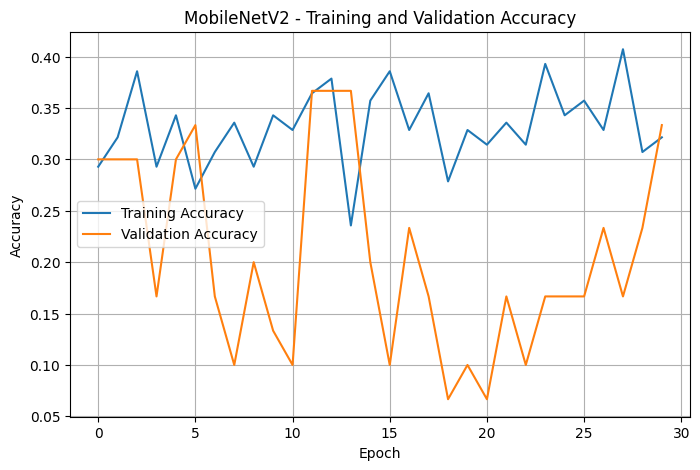

In [ ]:
# ============================================================
# Primary model accuracy curves
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_primary.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_primary.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("MobileNetV2 - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

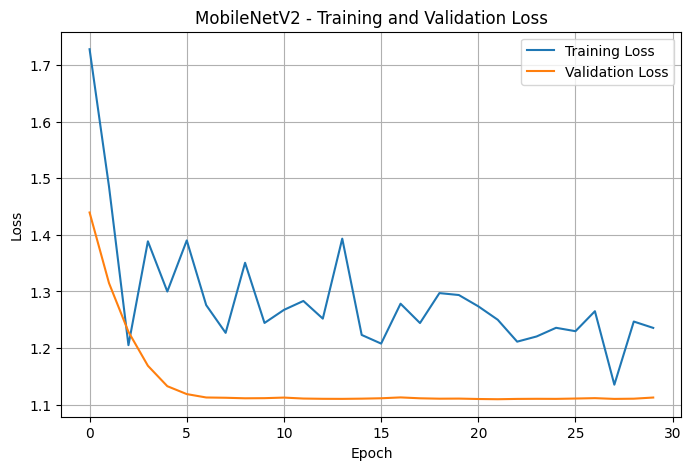

In [ ]:
# ============================================================
# Primary model loss curves
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_primary.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_primary.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

***Initial MobileNetV2 Experiment***

The initial frozen MobileNetV2 experiment produced a best validation
accuracy of 36.67%. This result was substantially below the custom CNN
baseline.

Before drawing conclusions, the input preprocessing configuration will
be reviewed to ensure consistency between the normalized dataset
pipeline and the preprocessing expected by the pretrained network.

In [72]:
# ============================================================
# Rebuild MobileNetV2 with corrected input preprocessing
# ============================================================

# Load pretrained MobileNetV2 again
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

# Model input: images are already in [0, 1]
inputs = layers.Input(shape=(224, 224, 3))

# Convert [0, 1] -> [0, 255]
x = layers.Rescaling(255.0)(inputs)

# Apply MobileNetV2 preprocessing
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Frozen pretrained feature extractor
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

primary_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="MobileNetV2_BUSI"
)

primary_model.summary()

Model: "MobileNetV2_BUSI"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [73]:
# ============================================================
# Compile corrected MobileNetV2
# ============================================================

primary_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(" Corrected MobileNetV2 compiled.")

 Corrected MobileNetV2 compiled.


In [74]:
# ============================================================
# Train corrected MobileNetV2
# ============================================================

primary_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

EPOCHS_PRIMARY = 30

history_primary = primary_model.fit(
    train_rgb_ds,
    validation_data=val_rgb_ds,
    epochs=EPOCHS_PRIMARY,
    callbacks=[primary_early_stopping],
    verbose=1
)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.3214 - loss: 1.5538 - val_accuracy: 0.4000 - val_loss: 1.0252
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.3500 - loss: 1.4891 - val_accuracy: 0.4667 - val_loss: 1.0078
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step - accuracy: 0.3286 - loss: 1.4018 - val_accuracy: 0.4667 - val_loss: 0.9919
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.4714 - loss: 1.2869 - val_accuracy: 0.5000 - val_loss: 0.9833
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.3429 - loss: 1.3642 - val_accuracy: 0.4667 - val_loss: 0.9746
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.4000 - loss: 1.3133 - val_accuracy: 0.5000 - val_loss: 0.9701
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.3429 - loss: 1.3954 - val_accuracy: 0.5000 - val_loss: 0.9554
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.3714 - loss: 1.3053 - val_accuracy: 0.5000 - val_loss: 0

In [75]:
# ============================================================
# Corrected MobileNetV2 training summary
# ============================================================

primary_best_val_accuracy = max(
    history_primary.history["val_accuracy"]
)

primary_best_val_loss = min(
    history_primary.history["val_loss"]
)

print(f"Best validation accuracy: {primary_best_val_accuracy:.4f}")
print(f"Best validation loss: {primary_best_val_loss:.4f}")
print(
    f"Epochs completed: "
    f"{len(history_primary.history['loss'])}"
)

Best validation accuracy: 0.7333
Best validation loss: 0.7658
Epochs completed: 30


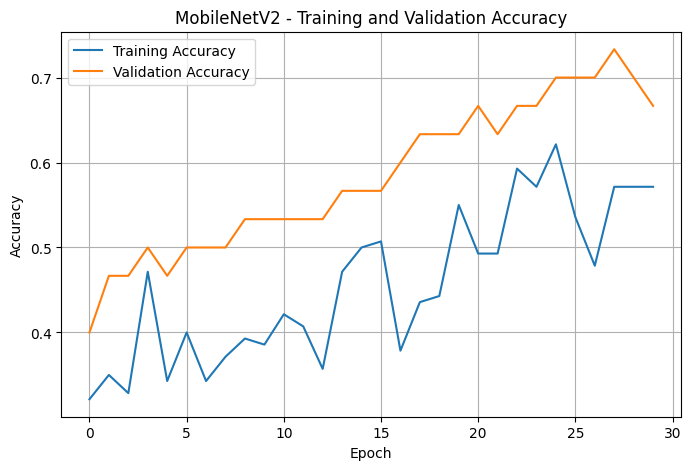

In [76]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_primary.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_primary.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("MobileNetV2 - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

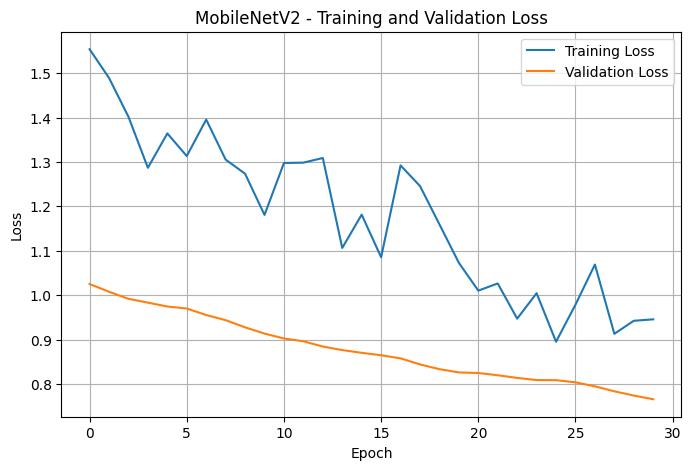

In [77]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_primary.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_primary.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

***Primary Model Training Results***

After correcting the input preprocessing for the pretrained MobileNetV2
model, the model achieved a best validation accuracy of 73.33% and a
best validation loss of 0.7658 over 30 training epochs.

The validation accuracy improved progressively during training, while
the validation loss decreased throughout the experiment. Compared with
the baseline CNN, the MobileNetV2 model achieved the same best
validation accuracy of 73.33%.

At this stage, the transfer learning model has not yet demonstrated an
improvement over the baseline based on validation accuracy. However,
the final comparison should also consider test-set performance and
class-level metrics, particularly recall for the Malignant class.

In [78]:
# ============================================================
# MobileNetV2 predictions on the test set
# ============================================================

y_true_primary = []
y_pred_primary = []

for images, labels in test_rgb_ds:
    probabilities = primary_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(probabilities, axis=1)

    y_true_primary.extend(labels.numpy())
    y_pred_primary.extend(predictions)

y_true_primary = np.array(y_true_primary)
y_pred_primary = np.array(y_pred_primary)

print("Number of test samples:", len(y_true_primary))

Number of test samples: 30


In [79]:
# ============================================================
# MobileNetV2 classification report
# ============================================================

print(
    classification_report(
        y_true_primary,
        y_pred_primary,
        target_names=CLASSES,
        digits=4
    )
)

              precision    recall  f1-score   support

      normal     0.6250    0.5556    0.5882         9
      benign     0.6667    0.5455    0.6000        11
   malignant     0.5385    0.7000    0.6087        10

    accuracy                         0.6000        30
   macro avg     0.6100    0.6003    0.5990        30
weighted avg     0.6114    0.6000    0.5994        30



In [80]:
# ============================================================
# MobileNetV2 malignant recall
# ============================================================

malignant_idx = class_to_idx["malignant"]

primary_malignant_recall = recall_score(
    y_true_primary,
    y_pred_primary,
    labels=[malignant_idx],
    average="macro"
)

print(
    f"MobileNetV2 Malignant Recall: "
    f"{primary_malignant_recall:.4f} "
    f"({primary_malignant_recall * 100:.2f}%)"
)

MobileNetV2 Malignant Recall: 0.7000 (70.00%)


***Primary Model Test Evaluation***

The MobileNetV2 model achieved a test accuracy of 60.00%, which is the
same overall test accuracy as the baseline CNN.

However, the class-level results show an important difference in
performance. The recall for the Malignant class increased from 30.00%
with the baseline CNN to 70.00% with MobileNetV2.

This represents a substantial improvement in the model's ability to
identify malignant cases. However, the recall for the Normal and
Benign classes decreased compared with the baseline.

These results demonstrate that overall accuracy alone does not provide
a complete picture of model performance. For this project, class-level
metrics, particularly Malignant recall, are important when comparing
models.

### 3.5 MobileNetV2 confusion matrix

MobileNetV2 Confusion Matrix:
[[5 0 4]
 [3 6 2]
 [0 3 7]]


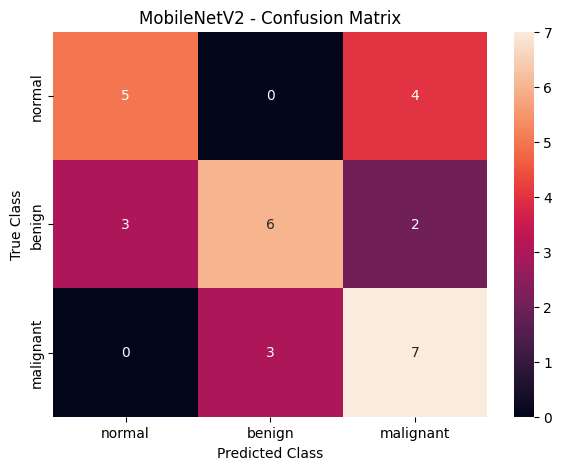

In [81]:
# ============================================================
# MobileNetV2 confusion matrix
# ============================================================

cm_primary = confusion_matrix(
    y_true_primary,
    y_pred_primary,
    labels=[0, 1, 2]
)

print("MobileNetV2 Confusion Matrix:")
print(cm_primary)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_primary,
    annot=True,
    fmt="d",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.title("MobileNetV2 - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

### 3.6 Sample Predictions

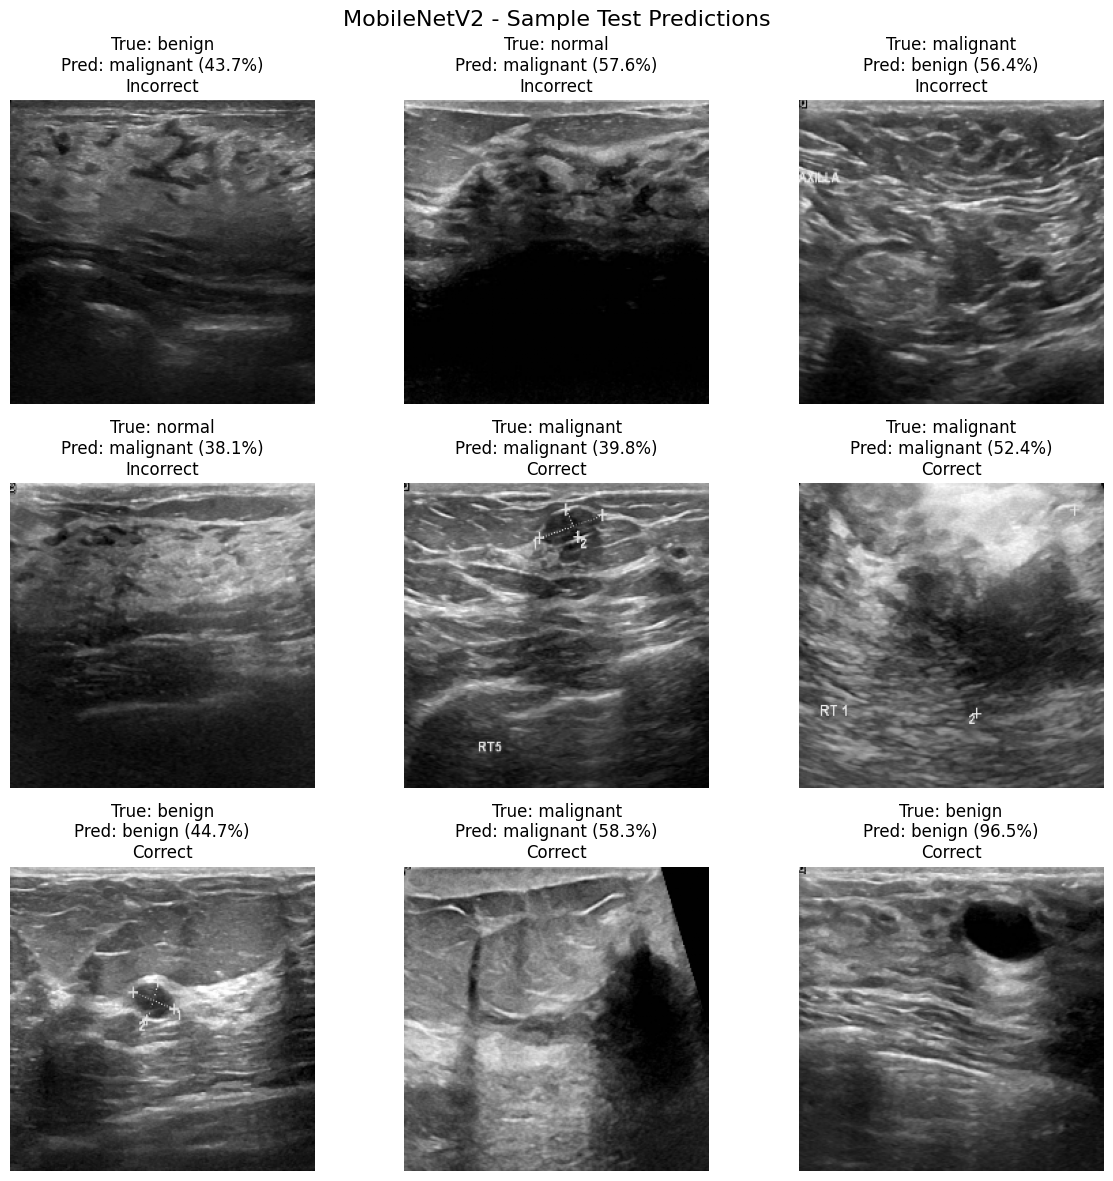

In [82]:
# ============================================================
# Sample predictions with input images
# ============================================================

NUM_SAMPLES = 9

# Reproducible selection
rng = np.random.default_rng(SEED)

selected_indices = rng.choice(
    len(test_paths),
    size=min(NUM_SAMPLES, len(test_paths)),
    replace=False
)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for ax, idx in zip(axes, selected_indices):

    image_path = test_paths[idx]
    true_label = test_labels[idx]

    # Load and preprocess image using the Assignment 2 pipeline
    image = load_and_preprocess_image(image_path)

    # Convert grayscale -> RGB for MobileNetV2
    image_rgb = tf.image.grayscale_to_rgb(image)

    # Add batch dimension
    input_tensor = tf.expand_dims(image_rgb, axis=0)

    # Prediction
    probabilities = primary_model.predict(
        input_tensor,
        verbose=0
    )[0]

    predicted_label = np.argmax(probabilities)
    confidence = probabilities[predicted_label]

    # Display grayscale image
    ax.imshow(
        tf.squeeze(image).numpy(),
        cmap="gray"
    )

    true_class = CLASSES[true_label]
    predicted_class = CLASSES[predicted_label]

    if true_label == predicted_label:
        result = "Correct"
    else:
        result = "Incorrect"

    ax.set_title(
        f"True: {true_class}\n"
        f"Pred: {predicted_class} "
        f"({confidence:.1%})\n"
        f"{result}"
    )

    ax.axis("off")

plt.suptitle(
    "MobileNetV2 - Sample Test Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [83]:
# ============================================================
# Find incorrect predictions
# ============================================================

incorrect_indices = np.where(
    y_true_primary != y_pred_primary
)[0]

print(
    f"Incorrect predictions: "
    f"{len(incorrect_indices)} / {len(y_true_primary)}"
)

Incorrect predictions: 12 / 30


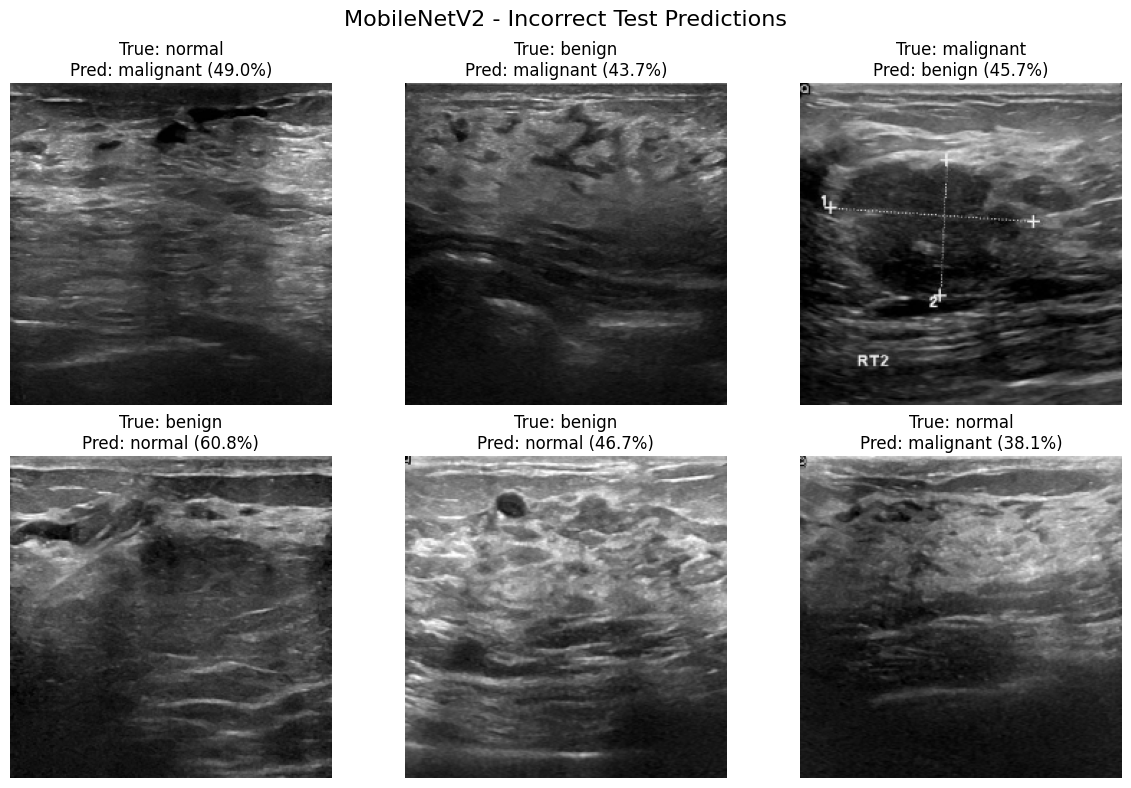

In [84]:
# ============================================================
# Visualize incorrect predictions
# ============================================================

NUM_INCORRECT = min(6, len(incorrect_indices))

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8)
)

axes = axes.flatten()

for ax, prediction_idx in zip(
    axes,
    incorrect_indices[:NUM_INCORRECT]
):

    image_path = test_paths[prediction_idx]
    true_label = y_true_primary[prediction_idx]
    predicted_label = y_pred_primary[prediction_idx]

    image = load_and_preprocess_image(image_path)

    # Get prediction confidence
    image_rgb = tf.image.grayscale_to_rgb(image)
    input_tensor = tf.expand_dims(image_rgb, axis=0)

    probabilities = primary_model.predict(
        input_tensor,
        verbose=0
    )[0]

    confidence = probabilities[predicted_label]

    ax.imshow(
        tf.squeeze(image).numpy(),
        cmap="gray"
    )

    ax.set_title(
        f"True: {CLASSES[true_label]}\n"
        f"Pred: {CLASSES[predicted_label]} "
        f"({confidence:.1%})"
    )

    ax.axis("off")

# Hide unused axes
for ax in axes[NUM_INCORRECT:]:
    ax.axis("off")

plt.suptitle(
    "MobileNetV2 - Incorrect Test Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [85]:
# ============================================================
# Primary model prediction summary
# ============================================================

correct_predictions = len(y_true_primary) - len(incorrect_indices)
test_accuracy = correct_predictions / len(y_true_primary)

print("=== MOBILE NETV2 PREDICTION SUMMARY ===")
print(f"Total test images       : {len(y_true_primary)}")
print(f"Correct predictions     : {correct_predictions}")
print(f"Incorrect predictions   : {len(incorrect_indices)}")
print(f"Test accuracy           : {test_accuracy:.2%}")

=== MOBILE NETV2 PREDICTION SUMMARY ===
Total test images       : 30
Correct predictions     : 18
Incorrect predictions   : 12
Test accuracy           : 60.00%


In [86]:
print(cm_primary)

[[5 0 4]
 [3 6 2]
 [0 3 7]]


***MobileNetV2 Confusion Matrix Analysis***

The MobileNetV2 confusion matrix shows that 7 of the 10 Malignant
test images were correctly classified, resulting in a Malignant recall
of 70.00%.

This represents a substantial improvement over the baseline CNN, which
correctly identified only 3 of the 10 Malignant images.

However, the improvement in Malignant detection is accompanied by
additional errors in the Normal class. Four of the 9 Normal images were
classified as Malignant, resulting in a Normal recall of 55.56%.

For the Benign class, 6 of 11 images were correctly classified,
resulting in a recall of 54.55%.

Overall, the confusion matrix shows that MobileNetV2 provides a better
balance for detecting Malignant cases than the baseline, but its
overall test accuracy remains 60.00%. The model therefore improves an
important class-specific metric without improving overall test
accuracy.

## Section 4. Model Evaluation and Diagnostics

This section evaluates and compares the baseline CNN and the primary
MobileNetV2 model using the quantitative results obtained on the
validation and test sets.

The analysis focuses on overall performance as well as class-level
performance, with particular attention to the Malignant class.

### 4.1 Quantitative comparison

In [88]:
# ============================================================
# Quantitative model comparison
# ============================================================

# Baseline metrics
baseline_val_accuracy = max(
    history_baseline.history["val_accuracy"]
)

baseline_test_accuracy = accuracy_score(
    y_true,
    y_pred
)

baseline_malignant_recall = recall_score(
    y_true,
    y_pred,
    labels=[class_to_idx["malignant"]],
    average="macro"
)

# MobileNetV2 metrics
primary_val_accuracy = max(
    history_primary.history["val_accuracy"]
)

primary_test_accuracy = accuracy_score(
    y_true_primary,
    y_pred_primary
)

primary_malignant_recall = recall_score(
    y_true_primary,
    y_pred_primary,
    labels=[class_to_idx["malignant"]],
    average="macro"
)

# Comparison table
comparison = pd.DataFrame({
    "Metric": [
        "Best Validation Accuracy",
        "Test Accuracy",
        "Malignant Recall"
    ],
    "Small CNN Baseline": [
        baseline_val_accuracy,
        baseline_test_accuracy,
        baseline_malignant_recall
    ],
    "MobileNetV2": [
        primary_val_accuracy,
        primary_test_accuracy,
        primary_malignant_recall
    ]
})

comparison_display = comparison.copy()

for col in ["Small CNN Baseline", "MobileNetV2"]:
    comparison_display[col] = (
        comparison_display[col] * 100
    ).round(2).astype(str) + "%"

comparison_display

,Metric,Small CNN Baseline,MobileNetV2
0,Best Validation Accuracy,73.33%,73.33%
1,Test Accuracy,60.0%,60.0%
2,Malignant Recall,30.0%,70.0%


### 4.2 Per-Class Performance

Per-class precision, recall, and F1-score are compared for the baseline
CNN and MobileNetV2.

This analysis is important because overall accuracy does not show how
the models perform for each diagnostic category. Particular attention
is given to the Malignant class because recall for this class is an
important success criterion for the project.

In [89]:
# ============================================================
# Per-class performance comparison
# ============================================================

baseline_report = classification_report(
    y_true,
    y_pred,
    target_names=CLASSES,
    output_dict=True
)

primary_report = classification_report(
    y_true_primary,
    y_pred_primary,
    target_names=CLASSES,
    output_dict=True
)

per_class_rows = []

for cls in CLASSES:
    per_class_rows.append({
        "Class": cls,
        "Baseline Precision": baseline_report[cls]["precision"],
        "Baseline Recall": baseline_report[cls]["recall"],
        "Baseline F1": baseline_report[cls]["f1-score"],
        "MobileNetV2 Precision": primary_report[cls]["precision"],
        "MobileNetV2 Recall": primary_report[cls]["recall"],
        "MobileNetV2 F1": primary_report[cls]["f1-score"]
    })

per_class_comparison = pd.DataFrame(per_class_rows)

per_class_display = per_class_comparison.copy()

metric_columns = [
    "Baseline Precision",
    "Baseline Recall",
    "Baseline F1",
    "MobileNetV2 Precision",
    "MobileNetV2 Recall",
    "MobileNetV2 F1"
]

per_class_display[metric_columns] = (
    per_class_display[metric_columns] * 100
).round(2)

per_class_display

,Class,Baseline Precision,Baseline Recall,Baseline F1,MobileNetV2 Precision,MobileNetV2 Recall,MobileNetV2 F1
0,normal,50.00,88.89,64.00,62.50,55.56,58.82
1,benign,63.64,63.64,63.64,66.67,54.55,60.00
2,malignant,100.00,30.00,46.15,53.85,70.00,60.87


### 4.3 Confusion matrix comparison

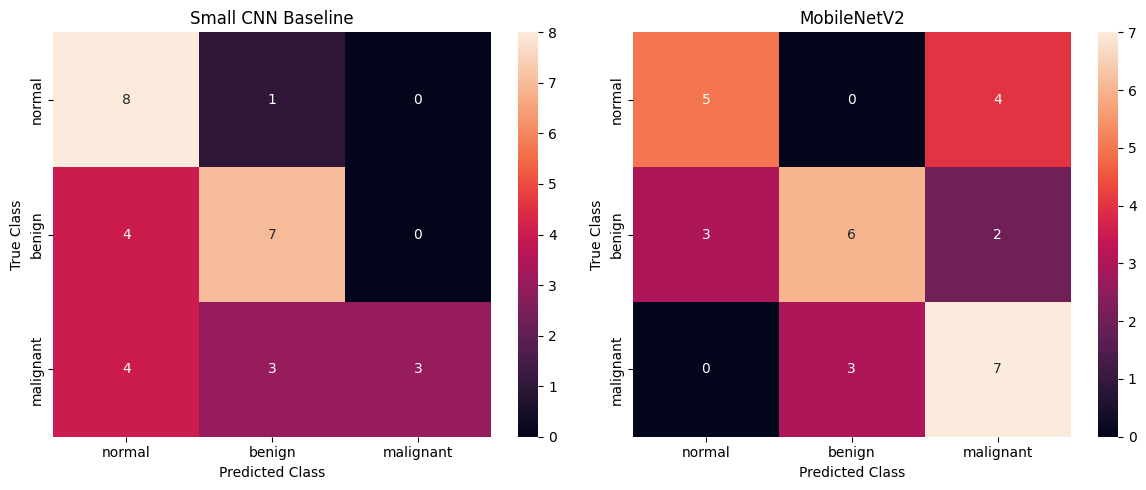

In [90]:
# ============================================================
# Confusion matrix comparison
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=axes[0]
)

axes[0].set_title("Small CNN Baseline")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("True Class")

sns.heatmap(
    cm_primary,
    annot=True,
    fmt="d",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=axes[1]
)

axes[1].set_title("MobileNetV2")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("True Class")

plt.tight_layout()
plt.show()



The confusion matrices show that the two models make different types
of classification errors.

The baseline CNN correctly identifies most Normal images but misses a
large proportion of Malignant images.

MobileNetV2 correctly identifies more Malignant images, but it also
produces more false-positive Malignant predictions for the Normal
class.

This demonstrates that the two models have different error profiles
even though their overall test accuracy is the same.

### 4.4 Overfitting and Underfitting Analysis



***Small CNN Baseline***

The baseline CNN showed evidence of overfitting. Training loss generally
decreased while validation loss increased after the best validation
point. The training and validation curves also became separated as
training progressed.

This suggests that the model learned the training examples more
effectively than it generalized to unseen validation images.

 ***MobileNetV2***

The MobileNetV2 model showed a more stable validation-loss pattern than
the baseline. Its validation loss decreased during training and did not
show the same pronounced increase observed in the baseline.

However, MobileNetV2 still did not reach the target validation accuracy
of 85%, indicating that stable training alone was not sufficient to
achieve the desired classification performance.

### 4.5 Strengths and Weaknesses

***Small CNN Baseline***

**Strengths**
- Simple and computationally lightweight.
- Strong recall for the Normal class.
- Provides a useful reference point for model comparison.

**Weaknesses**
- Test accuracy was only 60%.
- Malignant recall was only 30%.
- Training curves showed evidence of overfitting.

***MobileNetV2***

**Strengths**
- Malignant recall increased substantially to 70%.
- More malignant cases were correctly identified than with the baseline.
- Validation loss was more stable than with the baseline.

**Weaknesses**
- Test accuracy remained at 60%.
- Recall for Normal and Benign was lower than with the baseline.
- The 85% validation accuracy target was not achieved.

### 4.6 Alignment with the Original Objective

The original objective was to classify breast ultrasound images into
Normal, Benign, and Malignant categories and support the initial
screening process.

Neither the baseline CNN nor MobileNetV2 achieved the target validation
accuracy of 85%. Both models also achieved a test accuracy of 60.00%.

However, MobileNetV2 improved Malignant recall from 30.00% to 70.00%.
This improvement is relevant to the original objective because the
project places particular importance on identifying malignant cases.

The current results should therefore be considered experimental and
not suitable for clinical deployment. Additional model development
and optimization are required to improve overall performance and
generalization.

## Section 5. Model Optimization



### 5.1 Fine-Tuning Strategy

Fine-tuning is applied to the pretrained MobileNetV2 model in an
attempt to improve performance after the initial transfer learning
stage.

In the first MobileNetV2 experiment, the pretrained convolutional base
was frozen and only the newly added classification head was trained.

For fine-tuning, selected upper layers of MobileNetV2 are unfrozen so
that the model can adapt some of its learned visual features to the
breast ultrasound dataset.

A smaller learning rate is used during fine-tuning to reduce the risk
of damaging the pretrained representations.

The optimized model will be compared with the original MobileNetV2
model using validation accuracy, test accuracy, and Malignant recall.

#### Unfreeze the last layers

In [91]:
# ============================================================
# Fine-tuning MobileNetV2
# ============================================================

# Unfreeze the last part of the pretrained base model
base_model.trainable = True

# Freeze most layers and fine-tune only the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

print(
    "Trainable layers:",
    sum(layer.trainable for layer in base_model.layers)
)

print(
    "Total base-model layers:",
    len(base_model.layers)
)

Trainable layers: 20
Total base-model layers: 154


In [92]:
# Show the trainable status of the last layers
for layer in base_model.layers[-10:]:
    print(
        f"{layer.name:<30} "
        f"trainable={layer.trainable}"
    )

block_16_expand_BN             trainable=True
block_16_expand_relu           trainable=True
block_16_depthwise             trainable=True
block_16_depthwise_BN          trainable=True
block_16_depthwise_relu        trainable=True
block_16_project               trainable=True
block_16_project_BN            trainable=True
Conv_1                         trainable=True
Conv_1_bn                      trainable=True
out_relu                       trainable=True


 #### Recompile for fine-tuning

In [93]:
# ============================================================
# Recompile for fine-tuning
# ============================================================

primary_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(" Model recompiled for fine-tuning.")

 Model recompiled for fine-tuning.


#### Fine-tune MobileNetV2

In [94]:
# ============================================================
# Fine-tune MobileNetV2
# ============================================================

fine_tune_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

FINE_TUNE_EPOCHS = 20

history_finetune = primary_model.fit(
    train_rgb_ds,
    validation_data=val_rgb_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[fine_tune_early_stopping],
    verbose=1
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.5143 - loss: 1.0332 - val_accuracy: 0.6667 - val_loss: 0.7544
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.5214 - loss: 1.0366 - val_accuracy: 0.6667 - val_loss: 0.7391
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - accuracy: 0.5286 - loss: 0.9890 - val_accuracy: 0.7000 - val_loss: 0.7261
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.5714 - loss: 0.9945 - val_accuracy: 0.7333 - val_loss: 0.7137
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.5714 - loss: 0.9444 - val_accuracy: 0.7667 - val_loss: 0.7034
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.6429 - loss: 0.8687 - val_accuracy: 0.7667 - val_loss: 0.6920
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.6357 - loss: 0.7915 - val_accuracy: 0.7667 - val_loss: 0.6810
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 245ms/step - accuracy: 0.5786 - loss: 0.8199 - val_accuracy: 0.7333 - val_loss: 0

#### Fine-tuning results

In [95]:
# ============================================================
# Fine-tuning results
# ============================================================

finetune_best_val_accuracy = max(
    history_finetune.history["val_accuracy"]
)

finetune_best_val_loss = min(
    history_finetune.history["val_loss"]
)

print(
    f"Best fine-tuned validation accuracy: "
    f"{finetune_best_val_accuracy:.4f}"
)

print(
    f"Best fine-tuned validation loss: "
    f"{finetune_best_val_loss:.4f}"
)

print(
    f"Fine-tuning epochs completed: "
    f"{len(history_finetune.history['loss'])}"
)

Best fine-tuned validation accuracy: 0.7667
Best fine-tuned validation loss: 0.5991
Fine-tuning epochs completed: 20


#### Fine-tuned model predictions

In [96]:
# ============================================================
# Fine-tuned model predictions
# ============================================================

y_true_finetune = []
y_pred_finetune = []

for images, labels in test_rgb_ds:
    probabilities = primary_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true_finetune.extend(labels.numpy())
    y_pred_finetune.extend(predictions)

y_true_finetune = np.array(y_true_finetune)
y_pred_finetune = np.array(y_pred_finetune)

In [97]:
# ============================================================
# Fine-tuned classification report
# ============================================================

print(
    classification_report(
        y_true_finetune,
        y_pred_finetune,
        target_names=CLASSES,
        digits=4
    )
)

              precision    recall  f1-score   support

      normal     0.6154    0.8889    0.7273         9
      benign     1.0000    0.6364    0.7778        11
   malignant     0.7000    0.7000    0.7000        10

    accuracy                         0.7333        30
   macro avg     0.7718    0.7418    0.7350        30
weighted avg     0.7846    0.7333    0.7367        30



### 5.2 Optimization Results

Fine-tuning improved the performance of the MobileNetV2 model.

The best validation accuracy increased from 73.33% with the frozen
MobileNetV2 model to 76.67% after fine-tuning. Test accuracy also
increased from 60.00% to 73.33%.

The macro F1-score improved from 59.90% to 73.50%, indicating a better
overall balance across the three diagnostic classes.

The recall for the Malignant class remained at 70.00%. This is important
because the improvement in overall performance did not reduce the
model's ability to identify malignant cases.

Despite these improvements, the validation accuracy remains below the
85% target defined in Assignment 1. Therefore, further improvements
would be required before the model could be considered sufficiently
reliable for the original objective.

Fine-tuned MobileNetV2 Confusion Matrix:
[[8 0 1]
 [2 7 2]
 [3 0 7]]


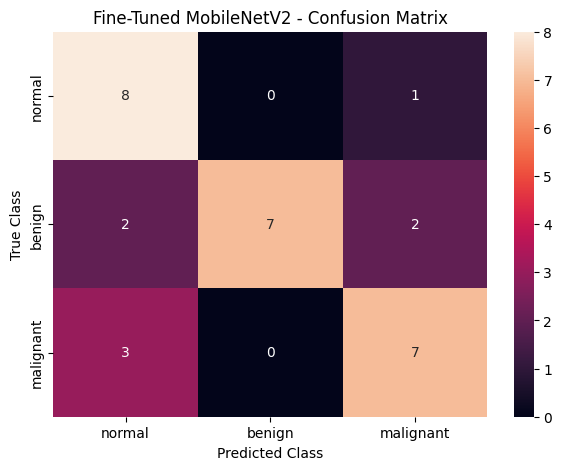

In [98]:
# ============================================================
# Fine-tuned MobileNetV2 confusion matrix
# ============================================================

cm_finetune = confusion_matrix(
    y_true_finetune,
    y_pred_finetune,
    labels=[0, 1, 2]
)

print("Fine-tuned MobileNetV2 Confusion Matrix:")
print(cm_finetune)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_finetune,
    annot=True,
    fmt="d",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.title("Fine-Tuned MobileNetV2 - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

### 5.3 Final comparison of all models

In [100]:
# ============================================================
# Fine-tuned MobileNetV2 metrics
# ============================================================

# Test accuracy
finetune_test_accuracy = accuracy_score(
    y_true_finetune,
    y_pred_finetune
)

# Malignant recall
finetune_malignant_recall = recall_score(
    y_true_finetune,
    y_pred_finetune,
    labels=[class_to_idx["malignant"]],
    average="macro"
)

# Classification report
finetune_report = classification_report(
    y_true_finetune,
    y_pred_finetune,
    target_names=CLASSES,
    output_dict=True
)

# ============================================================
# Final comparison
# ============================================================

final_comparison = pd.DataFrame({
    "Metric": [
        "Best Validation Accuracy",
        "Test Accuracy",
        "Malignant Recall",
        "Macro F1"
    ],

    "Small CNN Baseline": [
        baseline_val_accuracy,
        baseline_test_accuracy,
        baseline_malignant_recall,
        baseline_report["macro avg"]["f1-score"]
    ],

    "MobileNetV2": [
        primary_val_accuracy,
        primary_test_accuracy,
        primary_malignant_recall,
        primary_report["macro avg"]["f1-score"]
    ],

    "Fine-Tuned MobileNetV2": [
        finetune_best_val_accuracy,
        finetune_test_accuracy,
        finetune_malignant_recall,
        finetune_report["macro avg"]["f1-score"]
    ]
})

# ============================================================
# Display as percentages
# ============================================================

final_comparison_display = final_comparison.copy()

model_columns = [
    "Small CNN Baseline",
    "MobileNetV2",
    "Fine-Tuned MobileNetV2"
]

for col in model_columns:
    final_comparison_display[col] = (
        final_comparison_display[col] * 100
    ).round(2).astype(str) + "%"

final_comparison_display

,Metric,Small CNN Baseline,MobileNetV2,Fine-Tuned MobileNetV2
0,Best Validation Accuracy,73.33%,73.33%,76.67%
1,Test Accuracy,60.0%,60.0%,73.33%
2,Malignant Recall,30.0%,70.0%,70.0%
3,Macro F1,57.93%,59.9%,73.5%


## Section  6. Final Reflection

This project showed me that successful computer vision development requires more than overall accuracy. I learned the importance of a clear problem definition, a reliable preprocessing pipeline, and class-level evaluation, especially for the Malignant class. The baseline CNN achieved 73.33% validation accuracy and 60.00% test accuracy, while MobileNetV2 improved Malignant recall from 30.00% to 70.00%. Fine-tuning MobileNetV2 further improved performance to 76.67% validation accuracy and 73.33% test accuracy. However, the 85% target was not reached, showing that the small dataset of 200 images remains a major limitation. Future improvements could include a larger dataset, additional pretrained models, more systematic hyperparameter tuning, and further augmentation. Because this is a medical imaging task, the models should be considered experimental decision-support tools rather than clinical diagnostic systems. The project also highlighted practical challenges related to preprocessing, model compatibility, and GPU availability, and showed the importance of validating each stage of the workflow carefully.